# NAME: ABISHEK JS
# REG-NO: RA211026010307
# CLASS: AF-1

### Importing Libraries and Loading Dataset
In this initial step, we set up our environment by importing the necessary libraries and loading the dataset.
- **`pandas`**: we are using this library for data viewing and taking statistics out it
- **`read_csv`**: This function is used to load the `heart_disease_data.csv` file into a pandas DataFrame (`df`), making it easy to analyze and manipulate.
- **`df.head()`**: We call this method to preview the first 5 rows of our dataset. This is crucial for verifying that the data has been loaded correctly and for getting a preliminary understanding of the columns (features) and the type of data they contain (e.g., numerical, categorical).

In [14]:
from statistics import correlation

import pandas as pd

df = pd.read_csv("heart_disease_data.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### Displaying the Last Rows
- **`df.tail()`**: This method displays the last 5 rows of the DataFrame. 
While `head()` gives us a look at the beginning, `tail()` is equally important. It helps us ensure that the entire dataset was read correctly all the way to the end, without any unexpected footers, trailing null values, or data corruption at the bottom of the CSV file.

In [15]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


### Dataset Information and Dimensions
To fully grasp the scale and structure of our dataset, we examine its dimensions and data types:
- **`df.shape`**: Returns a tuple representing the dimensionality of the DataFrame `(number of rows, number of columns)`. This tells us exactly how many records (patients) and features we have.
- **`df.size`**: Returns the total number of elements in the DataFrame (rows multiplied by columns).
- **`df.info()`**: This provides a concise summary of the DataFrame. It is incredibly useful for seeing the data type (e.g., `int64`, `float64`, `object`) of each column, the index dtype, and, most importantly, the number of non-null values. This is our first clue if there is any missing data that needs to be addressed.

In [16]:
print(df.shape)
print(df.size)
print(df.info())


(303, 14)
4242
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None


### Checking for Missing Values
Data quality is paramount in machine learning and statistics. Missing values can lead to biased models or cause algorithms to fail.
- **`df.isnull().sum()`**: This command checks every single cell in the DataFrame to see if it is null (or NaN). By chaining `.sum()`, we aggregate these boolean results, giving us a clear, column-by-column count of how many missing values exist. A result of `0` for all columns means our dataset is clean and complete.

In [17]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

### Displaying Column Names
- **`df.columns`**: This attribute returns an index object containing all the column labels of our DataFrame. 
Reviewing the column names helps us familiarize ourselves with the features we will be working with, such as `age`, `sex`, `trestbps` (resting blood pressure), `chol` (serum cholestoral), and our target variable `target` (presence of heart disease).

In [18]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')

### Extracting a Random Sample
- **`df.sample()`**: This method returns a random sample of items from an axis of object. By default, it returns a single random row.
Unlike `head()` or `tail()`, a random sample gives us an unbiased look at the data, helping us to spot any anomalies or inconsistencies that might not be present at the very beginning or end of the dataset.

In [19]:
df.sample()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
91,57,1,0,132,207,0,1,168,1,0.0,2,0,3,1


### Descriptive Statistics Summary
Before diving into complex analysis, it's essential to understand the basic statistical properties of our numerical data.
- **`df.describe()`**: This powerful method computes a summary of statistics pertaining to the DataFrame columns. 
It provides the count, mean, standard deviation (std), minimum (min), maximum (max), and the 25th, 50th (median), and 75th percentiles. This information is vital for understanding the central tendency, dispersion, and shape of the dataset's distribution, allowing us to identify potential outliers or heavily skewed features.

In [20]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# Getting the problablity values

### Calculating Basic and Joint Probabilities
In this section, we apply fundamental probability concepts to our dataset by defining specific events:
- **Event A (`target == 1`)**: The probability that a random patient in the dataset has heart disease.
- **Event B (`chol > 240`)**: The probability that a random patient has a high cholesterol level (greater than 240 mg/dl).
We use the `.mean()` function on a boolean series to easily calculate these probabilities (since True is treated as 1 and False as 0). Furthermore, we calculate the joint probability **P(A and B)**, which is the probability of a patient having both heart disease AND high cholesterol simultaneously.

In [21]:
#  event - A -> Heart disease
# event B - High cholestrol (>240)

A = df["target"] == 1
B = df["chol"] > 240

P_A = A.mean()
P_B = B.mean()

P_A_and_B = (A & B).mean()

print(f"P_A = {P_A}")
print(f"P_B = {P_B}")
print(f"P_A_and_B = {P_A_and_B}")

P_A = 0.5445544554455446
P_B = 0.49834983498349833
P_A_and_B = 0.2376237623762376


### Calculating Variance
Variance measures how far a set of numbers is spread out from their average value.
- **`df["age"].var()` and `df["chol"].var()`**: We calculate the variance for the `age` and `chol` features. 
A high variance indicates that the data points are very spread out around the mean, while a low variance indicates that they are tightly clustered. Understanding the variance is crucial for feature scaling and for algorithms that are sensitive to the magnitude of features.

In [22]:
# variance for the heart disease data set on the feature age

variance_age = df["age"].var()
print("Varaince for the feature age is:", variance_age)

variance_chol = df["chol"].var()
print("Varaince for the feature chol is:", variance_chol)

Varaince for the feature age is: 82.48455838961378
Varaince for the feature chol is: 2686.42674797281


### Conditional Probability and Bayes' Theorem
Conditional probability is the probability of one event occurring with some relationship to one or more other events.
- **`P_A_given_P_B`**: Here, we calculate the probability of a patient having heart disease *given* that we already know they have high cholesterol. The formula used is **P(A|B) = P(A ∩ B) / P(B)**.
- **Bayes' Theorem check**: We also demonstrate a simple application of Bayes' theorem to verify our conditional probability calculation, linking the concepts of joint, marginal, and conditional probabilities.

In [23]:
# conditional problablity given heart disease with cholestrol greater than 240

P_A_given_P_B = P_A_and_B/P_B
Bayes = (P_A_given_P_B*P_B)/P_B
print(f"P_A_given_P_B = {P_A_given_P_B}")
print(f"Bayes = {Bayes}")

P_A_given_P_B = 0.4768211920529801
Bayes = 0.4768211920529801


### Calculating Standard Deviation
Standard deviation is the square root of the variance and is often preferred because it is expressed in the same units as the original data.
- **`df["age"].std()`**: We compute the standard deviation of the `age` feature. This tells us, on average, how much the ages in our dataset deviate from the mean age. It is a highly intuitive measure of statistical dispersion.

In [24]:
std = df["age"].std()
print("Standard Deviation =", std)

Standard Deviation = 9.082100989837857


### Computing the Covariance Matrix
Covariance indicates the direction of the linear relationship between variables.
- **`df[features].cov()`**: We select a specific subset of continuous features (`age`, `trestbps`, `chol`, `thalach`, `oldpeak`) and compute their covariance matrix.
A positive covariance means that the variables tend to move in the same direction, while a negative covariance means they move in opposite directions. However, covariance values are not normalized, making it difficult to determine the *strength* of the relationship, which leads us to correlation.

In [30]:
# covariance for the features ["age", "trestbps", "chol", "thalach", "oldpeak"]

features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

covariance = df[features].cov()

print("Covariance =", covariance)

Covariance =                  age    trestbps         chol     thalach   oldpeak
age        82.484558   44.495902   100.585076  -82.903318  2.214583
trestbps   44.495902  307.586453   111.967215  -18.759131  3.934486
chol      100.585076  111.967215  2686.426748  -11.800494  3.246794
thalach   -82.903318  -18.759131   -11.800494  524.646406 -9.153518
oldpeak     2.214583    3.934486     3.246794   -9.153518  1.348095


### Visualizing Data: Probability Density Plot
Visualizations are key to understanding data distributions.
- **`sns.kdeplot()`**: We use Seaborn's Kernel Density Estimate (KDE) plot to visualize the probability density of the `age` feature. 
Unlike a histogram which bins data, a KDE plot smooths the observations with a Gaussian kernel, producing a continuous probability density curve. This helps us see the exact shape of the age distribution—whether it's normal, bimodal, or skewed.

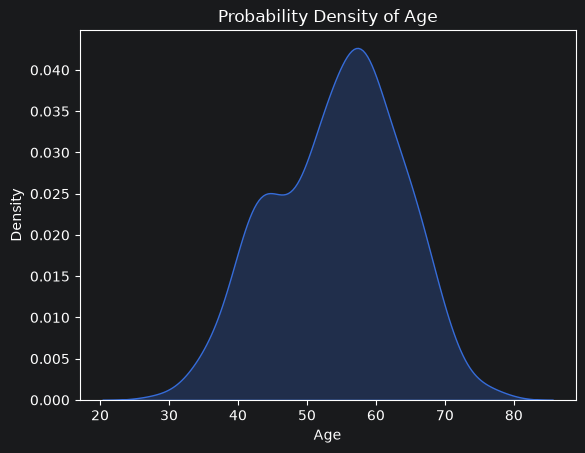

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(data=df, x="age", fill=True)

plt.xlabel("Age")
plt.ylabel("Density")
plt.title("Probability Density of Age")
plt.show()

### Visualizing Relationships: Correlation Matrix and Heatmap
Correlation is a normalized version of covariance, scaling values strictly between -1 and 1.
- **`df[features].corr()`**: We compute Pearson's correlation coefficient for our selected features. A value close to 1 implies a strong positive relationship, -1 implies a strong negative relationship, and 0 implies no linear relationship.
- **`sns.heatmap()`**: To make the correlation matrix easily interpretable, we plot it as a heatmap. The `annot=True` parameter adds the numerical values inside the cells, and the `cmap="coolwarm"` parameter applies a color gradient, allowing us to instantly spot highly correlated features at a glance.

correlation matrix
               age  trestbps      chol   thalach   oldpeak
age       1.000000  0.279351  0.213678 -0.398522  0.210013
trestbps  0.279351  1.000000  0.123174 -0.046698  0.193216
chol      0.213678  0.123174  1.000000 -0.009940  0.053952
thalach  -0.398522 -0.046698 -0.009940  1.000000 -0.344187
oldpeak   0.210013  0.193216  0.053952 -0.344187  1.000000


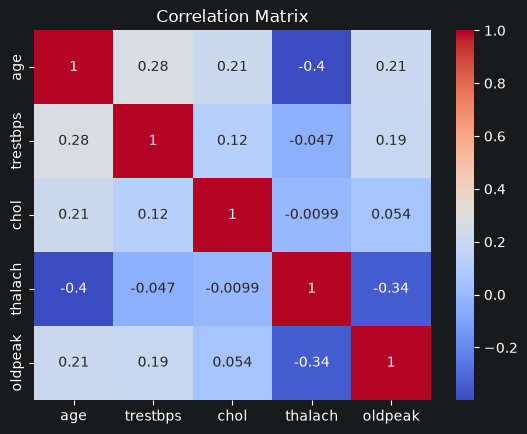

In [31]:
import seaborn as sns

features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

correlation = df[features].corr()

print("correlation matrix")
print(correlation)

sns.heatmap(correlation, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()